In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

In [3]:
transformation = transforms.Compose([
    transforms.Resize((200, 200)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.ToTensor()
])

realwaste_img = datasets.ImageFolder("realwaste-main/RealWaste/", transform=transformation)

In [4]:
# Get number of classes in the dataset
num_classes = len(realwaste_img.classes)
print(f"Dataset contains {num_classes} classes: {realwaste_img.classes}")

Dataset contains 9 classes: ['Cardboard', 'Food Organics', 'Glass', 'Metal', 'Miscellaneous Trash', 'Paper', 'Plastic', 'Textile Trash', 'Vegetation']


In [5]:
# Split dataset into training and test set
train_ratio = 0.7
train_size = int(train_ratio * len(realwaste_img))
test_size = len(realwaste_img) - train_size
train_dataset, test_dataset = random_split(realwaste_img,[train_size, test_size])
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=True)

In [6]:
def show_image(img_tensor):
    img = img_tensor.numpy().transpose((1, 2, 0))
    img = np.clip(img, 0, 1)
    plt.figure(figsize=(2,2))
    plt.imshow(img)
    plt.axis('off')
    plt.show()

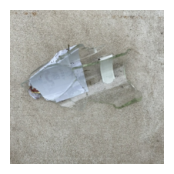

Label: Glass


In [7]:
images, labels = next(iter(train_loader))
show_image(images[0])
print(f"Label: {realwaste_img.classes[labels[0]]}")